In [1]:
import pandas as pd
import numpy as np
import tenseal as ts
import time
import pickle
import os
import matplotlib.pyplot as plt

# Load PCA Compressed Embeddings

In [2]:
compressed_df = pd.read_csv(
    "../Outputs/Notebook_05/normalized_features.csv"
)

print("Shape:", compressed_df.shape)

compressed_df.head()

Shape: (14446, 128)


,0,1,2,3,4,5,6,7,8,9,...,118,119,120,121,122,123,124,125,126,127
0,0.526823,0.094932,0.007958,0.025956,-0.007479,-0.095432,0.082533,-0.036731,-0.147702,-0.257490,...,0.010873,-0.002952,0.020022,-0.107499,-0.023784,0.005837,-0.056209,-0.011746,0.034397,0.014215
1,-0.262369,0.129529,0.145536,0.070387,0.208729,-0.102281,0.051180,0.045606,-0.169462,-0.241096,...,-0.039718,0.032698,0.001298,-0.039211,-0.036072,0.000173,0.013546,-0.007122,-0.024626,0.032152
2,-0.726508,-0.259545,0.040756,0.109367,0.154611,-0.148783,-0.108108,0.107226,0.033466,-0.065863,...,0.015677,0.035430,-0.011306,0.002234,-0.004228,-0.014251,-0.016461,-0.027604,-0.002739,0.000476
3,-0.032377,0.295062,-0.124254,0.233385,0.320078,-0.060603,-0.100276,-0.333794,0.097891,0.092188,...,0.033913,-0.037903,0.022925,-0.056097,0.073470,0.005898,-0.096461,0.003842,0.065025,0.020790
4,0.037551,0.250856,0.055269,0.368742,0.144624,-0.099008,-0.150893,-0.284881,0.233642,0.115804,...,-0.022512,-0.008519,0.002903,-0.037583,-0.000397,0.023426,-0.010204,-0.002801,0.037486,-0.031773


In [3]:
print(compressed_df.columns[:10])

Index(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9'], dtype='str')


# Analyze Embedding Dataset

In [4]:
print(compressed_df.info())

compressed_df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 14446 entries, 0 to 14445
Columns: 128 entries, 0 to 127
dtypes: float64(128)
memory usage: 14.1 MB
None


,0,1,2,3,4,5,6,7,8,9,...,118,119,120,121,122,123,124,125,126,127
count,14446.000000,14446.000000,14446.000000,14446.000000,14446.000000,14446.000000,14446.000000,14446.000000,14446.000000,14446.000000,...,14446.000000,14446.000000,14446.000000,14446.000000,14446.000000,14446.000000,14446.000000,14446.000000,14446.000000,14446.000000
mean,-0.016514,0.022439,-0.009253,0.000245,0.008800,0.001349,0.004526,-0.006183,-0.002604,0.001284,...,0.000007,0.000120,0.000122,-0.000027,0.000001,0.000048,-0.000055,0.000012,0.000018,0.000165
std,0.465599,0.280843,0.248047,0.227670,0.209127,0.193361,0.177247,0.172435,0.157719,0.150972,...,0.029683,0.029921,0.029581,0.029513,0.029121,0.029086,0.028932,0.029022,0.028355,0.028564
min,-0.889834,-0.812611,-0.798779,-0.688724,-0.671024,-0.658934,-0.628714,-0.611122,-0.552513,-0.585918,...,-0.127406,-0.123369,-0.122299,-0.113327,-0.118681,-0.121118,-0.113233,-0.118982,-0.126877,-0.136596
25%,-0.453747,-0.143932,-0.178050,-0.158508,-0.129907,-0.129952,-0.114398,-0.116416,-0.107848,-0.098368,...,-0.019913,-0.019946,-0.019519,-0.019847,-0.019351,-0.019202,-0.018921,-0.019060,-0.018972,-0.018859
50%,0.057206,0.063388,0.009193,-0.006001,0.014399,0.003928,0.004587,0.000532,-0.005218,0.001630,...,-0.000126,0.000114,0.000317,0.000153,-0.000121,0.000173,0.000216,0.000070,0.000380,0.000080
75%,0.393416,0.233457,0.172074,0.157083,0.157106,0.139697,0.123414,0.105912,0.100320,0.102232,...,0.019707,0.019938,0.019645,0.019766,0.019395,0.019575,0.019131,0.018743,0.018874,0.019004
max,0.847277,0.707061,0.652304,0.729313,0.684817,0.580063,0.631550,0.618491,0.632616,0.581836,...,0.110340,0.124845,0.138562,0.133688,0.112413,0.109229,0.114619,0.120319,0.103762,0.128392


# Create CKKS Encryption Context

In [5]:
context = ts.context(
    ts.SCHEME_TYPE.CKKS,
    poly_modulus_degree=8192,
    coeff_mod_bit_sizes=[60,40,40,60]
)

context.global_scale = 2**40

context.generate_galois_keys()

context.generate_relin_keys()

print("CKKS Context Created Successfully")

CKKS Context Created Successfully


# Display CKKS Parameters

In [6]:
print("Global Scale:", context.global_scale)

Global Scale: 1099511627776.0


# Extract Image IDs and Feature Vectors

In [7]:
features = compressed_df.values

print(
    "Feature Shape:",
    features.shape
)

Feature Shape: (14446, 128)


# Visualize Sample Embedding

In [8]:
print(features[0][:20])

[ 0.52682268  0.0949319   0.00795764  0.02595625 -0.00747899 -0.09543237
  0.08253346 -0.03673115 -0.14770175 -0.25749004  0.3477564   0.13829871
 -0.10270857 -0.12401098  0.00333362 -0.15110449  0.03785146 -0.10627621
 -0.05149326 -0.07689646]


# Encrypt Single Sample Embedding

In [9]:
sample_encrypted = ts.ckks_vector(
    context,
    features[0].tolist()
)

print("Sample Encryption Successful")

Sample Encryption Successful


# Analyze Encrypted Template Size

In [10]:
serialized_sample = sample_encrypted.serialize()

print(
    "Encrypted Template Size:",
    len(serialized_sample),
    "bytes"
)

Encrypted Template Size: 334296 bytes


# Encrypt Complete Embedding Dataset

In [11]:
encrypted_embeddings = []

encryption_times = []

for row in features:

    start_time = time.time()

    encrypted_vector = ts.ckks_vector(
        context,
        row.tolist()
    )

    end_time = time.time()

    encrypted_embeddings.append(
        encrypted_vector.serialize()
    )

    encryption_times.append(
        end_time - start_time
    )

print("Dataset Encryption Completed")

Dataset Encryption Completed


# Save Encrypted Templates

In [12]:
os.makedirs(
    "../Outputs/Notebook_06",
    exist_ok=True
)

with open(
    "../Outputs/Notebook_06/encrypted_embeddings.pkl",
    "wb"
) as f:

    pickle.dump(
        encrypted_embeddings,
        f
    )

print("Encrypted Templates Saved")

Encrypted Templates Saved


# Generate Encryption Statistics

In [13]:
stats_df = pd.DataFrame({

    "Embedding_ID": range(
        len(encryption_times)
    ),

    "Encryption_Time": encryption_times

})

stats_df.to_csv(
    "../Outputs/Notebook_06/encryption_statistics.csv",
    index=False
)

stats_df.head()

,Embedding_ID,Encryption_Time
0,0,0.013900
1,1,0.012338
2,2,0.009390
3,3,0.010127
4,4,0.011903


# Compute Average Encryption Time

In [14]:
avg_time = np.mean(encryption_times)

print(
    "Average Encryption Time:",
    avg_time,
    "seconds"
)

Average Encryption Time: 0.007693204889003052 seconds


# Memory Usage Analysis

In [15]:
memory_usage = []

for item in encrypted_embeddings:

    memory_usage.append(
        len(item)
    )

memory_df = pd.DataFrame({

    "Embedding_ID": range(
        len(memory_usage)
    ),

    "Memory_Bytes": memory_usage

})

memory_df.to_csv(
    "../Outputs/Notebook_06/memory_usage_analysis.csv",
    index=False
)

print(
    "Average Memory Usage:",
    np.mean(memory_usage),
    "bytes"
)

Average Memory Usage: 334291.2349439291 bytes


# Encryption Time Distribution

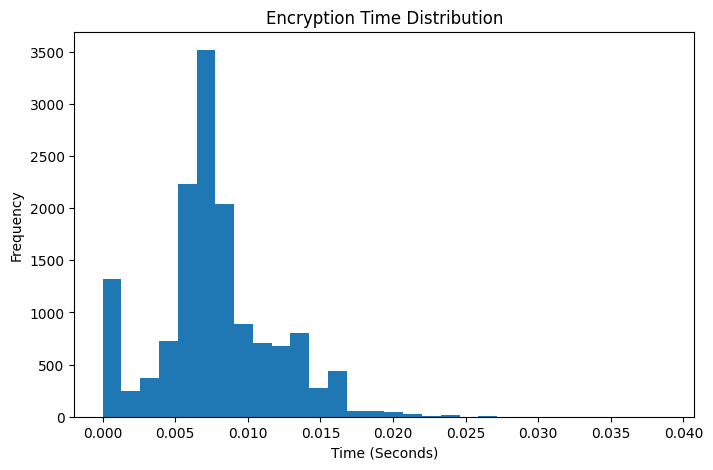

In [16]:
plt.figure(figsize=(8,5))

plt.hist(
    encryption_times,
    bins=30
)

plt.title("Encryption Time Distribution")

plt.xlabel("Time (Seconds)")

plt.ylabel("Frequency")

plt.savefig(
    "../Outputs/Notebook_06/encryption_time_distribution.png"
)

plt.show()

# Memory Usage Distribution

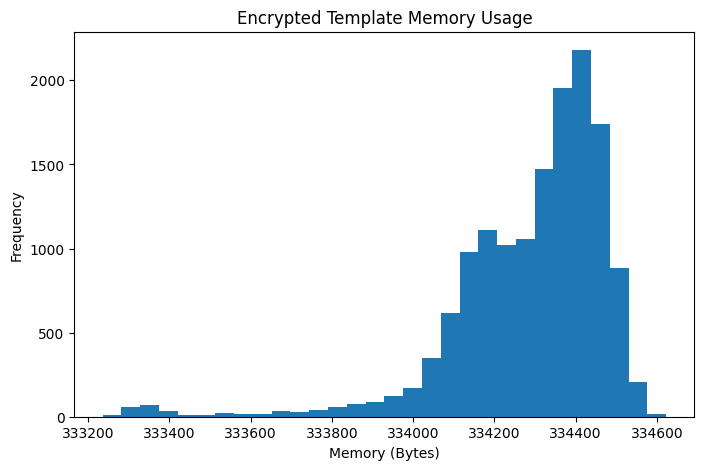

In [17]:
plt.figure(figsize=(8,5))

plt.hist(
    memory_usage,
    bins=30
)

plt.title("Encrypted Template Memory Usage")

plt.xlabel("Memory (Bytes)")

plt.ylabel("Frequency")

plt.savefig(
    "../Outputs/Notebook_06/memory_usage_distribution.png"
)

plt.show()

# Encryption Statistics Summary

In [18]:
summary_df = pd.DataFrame({
    "Metric":[
        "Average Encryption Time",
        "Average Memory Usage"
    ],
    "Value":[
        np.mean(encryption_times),
        np.mean(memory_usage)
    ]
})

summary_df.to_csv(
    "../Outputs/Notebook_06/encryption_summary.csv",
    index=False
)

summary_df

,Metric,Value
0,Average Encryption Time,0.007693
1,Average Memory Usage,334291.234944


In [19]:
import pickle

with open(
    "../Outputs/Notebook_06/encrypted_embeddings.pkl",
    "rb"
) as f:

    encrypted_embeddings = pickle.load(f)

print(type(encrypted_embeddings))
print(len(encrypted_embeddings))

<class 'list'>
14446


# Save CKKS Context

In [20]:
context_bytes = context.serialize(
    save_secret_key=True
)

with open(
    "../Outputs/Notebook_06/context.pkl",
    "wb"
) as f:

    pickle.dump(
        context_bytes,
        f
    )

print("CKKS Context Saved")

CKKS Context Saved


In [21]:
import pickle

with open(
    "../Outputs/Notebook_06/context.pkl",
    "rb"
) as f:

    context_bytes = pickle.load(f)

print(type(context_bytes))

<class 'bytes'>


In [22]:
import os

size_mb = os.path.getsize(
    "../Outputs/Notebook_06/encrypted_embeddings.pkl"
) / (1024*1024)

print(
    f"{size_mb:.2f} MB"
)

4605.54 MB


In [23]:
print(features.shape)

print(type(encrypted_embeddings[0]))

(14446, 128)
<class 'bytes'>
